In [1]:
import mne

file_path = "1 open eyes.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw)
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info["sfreq"])
print("Shape:", raw.get_data().shape)
print("Duration (sec):", raw.times[-1])


Matplotlib is building the font cache; this may take a moment.


Extracting EDF parameters from 1 open eyes.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7624  =      0.000 ...    60.992 secs...
<RawEDF | 1 open eyes.edf, 6 x 7625 (61.0 s), ~367 KiB, data loaded>
Channels: ['O1', 'T3', 'Fp1', 'Fp2', 'T4', 'O2']
Sampling rate: 125.0
Shape: (6, 7625)
Duration (sec): 60.992


Using matplotlib as 2D backend.


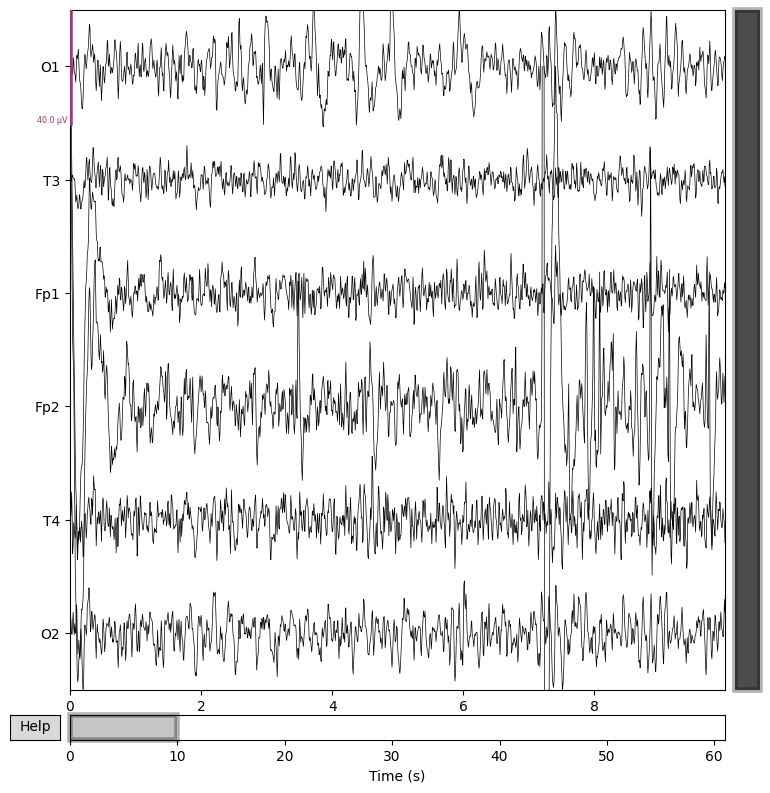

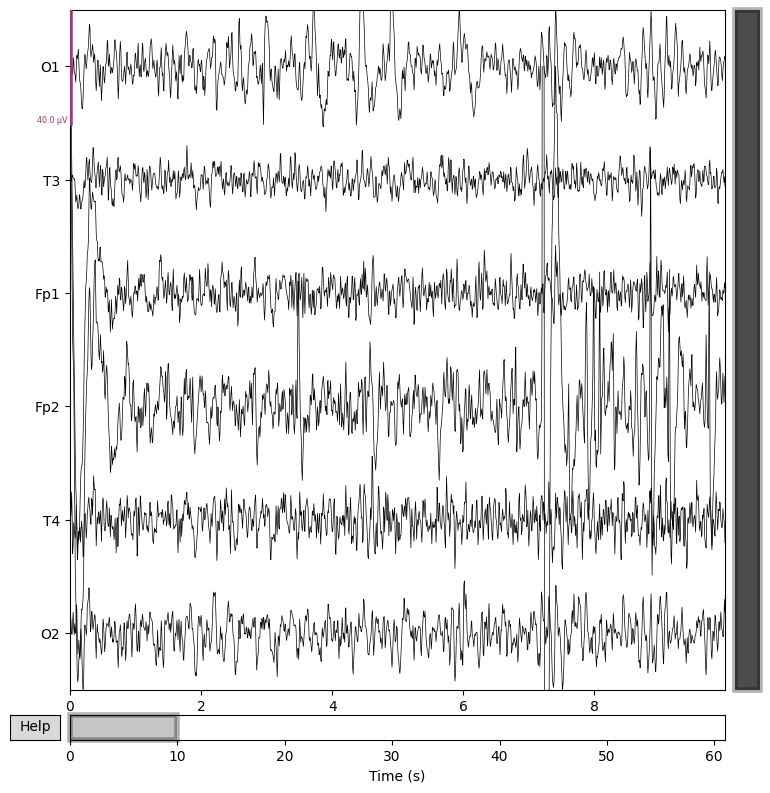

In [2]:
raw.plot()


In [5]:
epoch_duration = 10
threshold_factor = 2.0

data = raw.get_data()
sfreq = raw.info["sfreq"]

samples_per_epoch = int(epoch_duration * sfreq)
n_channels, n_samples = data.shape
n_epochs = n_samples // samples_per_epoch

trimmed_samples = n_epochs * samples_per_epoch
data_trimmed = data[:, :trimmed_samples]

epoch_max_matrix = np.zeros((n_epochs, n_channels))

for epoch_idx in range(n_epochs):
    start = epoch_idx * samples_per_epoch
    end = start + samples_per_epoch
    epoch = data_trimmed[:, start:end]
    epoch_max_matrix[epoch_idx] = np.max(np.abs(epoch), axis=1)

channel_typical_max = np.median(epoch_max_matrix, axis=0)

good_epoch_indices = []
bad_epoch_indices = []

for epoch_idx in range(n_epochs):
    epoch_max_amp = epoch_max_matrix[epoch_idx]
    is_bad = np.any(epoch_max_amp > threshold_factor * channel_typical_max)

    if is_bad:
        bad_epoch_indices.append(epoch_idx)
    else:
        good_epoch_indices.append(epoch_idx)

print("Всего эпох:", n_epochs)
print("Хороших эпох:", len(good_epoch_indices))
print("Плохих эпох:", len(bad_epoch_indices))
print("Плохие эпохи:", bad_epoch_indices)
print("Типичный максимум по каналам:", channel_typical_max)


Всего эпох: 6
Хороших эпох: 4
Плохих эпох: 2
Плохие эпохи: [0, 3]
Типичный максимум по каналам: [3.08232242e-05 1.33669032e-05 1.83108263e-05 6.66514076e-05
 2.02639811e-05 2.10879683e-05]


In [6]:
good_segments = []

for epoch_idx in good_epoch_indices:
    start = epoch_idx * samples_per_epoch
    end = start + samples_per_epoch
    good_segments.append(data_trimmed[:, start:end])

clean_data = np.concatenate(good_segments, axis=1)

print("Исходная форма:", data.shape)
print("Очищенная форма:", clean_data.shape)


Исходная форма: (6, 7625)
Очищенная форма: (6, 5000)


Creating RawArray with float64 data, n_channels=6, n_times=5000
    Range : 0 ... 4999 =      0.000 ...    39.992 secs
Ready.


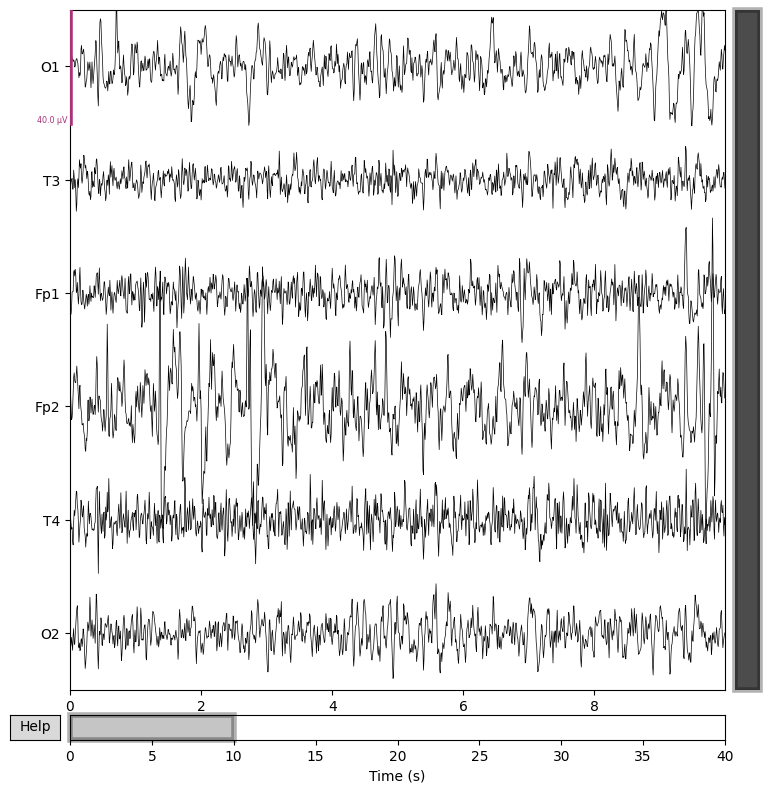

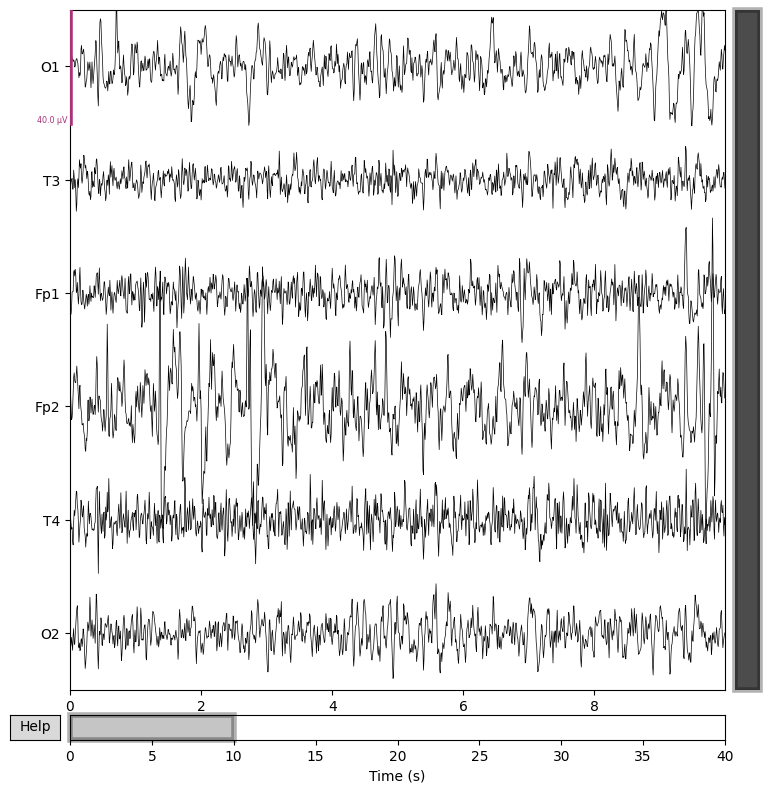

In [7]:
raw_clean = mne.io.RawArray(clean_data, raw.info.copy())
raw_clean.plot()
